# LSTM Baseline – 1-hour Ahead Heat Demand Forecasting

This notebook trains simple, readable TensorFlow/Keras LSTM models for **1-hour ahead** heat demand forecasting for TalTech campus buildings. It reuses the same cleaned hourly datasets and train/test split as the baselines in `02_establishing_baselines_27022026.ipynb`, and adds a configurable feature selection system (weather, sensor, calendar, and optional EHR building attributes).

In [27]:
# Section 0 — Imports and Configuration

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Matplotlib defaults for notebook plots
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 5)

# Project paths (relative to thesis-project root)
PROJECT_ROOT = Path.cwd()
CLEAN_DATA_DIR = PROJECT_ROOT / "data" / "clean"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

WEATHER_FILE = CLEAN_DATA_DIR / "weather_features_hourly.csv"

# Core dataset/config choices
SPLIT_DATE = "2024-01-01 00:00:00"  # chronological train/val/test split boundary
PRIMARY_BUILDINGS = ["U06", "U05"]  # thesis focus buildings

# Buildings to include for broader campus / portfolio-style analysis;
# skips NRG since it has different structure
CAMPUS_BUILDINGS = [
    "GEO", "ICO", "LIB", "SOC", "STU",
    "U01", "U01U02", "U02", "U02B",
    "U03", "U03B", "U04", "U04B",
    "U05", "U05B", "U06", "U06A",
]

# Global modeling hyperparameters (simple, but can be tuned later)
LOOKBACK_HOURS = 24  # history window length for the LSTM
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MONITOR = "val_loss"
EARLY_STOPPING_MODE = "min"
EARLY_STOPPING_RESTORE_BEST_WEIGHTS = True

# Heating-season configuration
TRAIN_HEATING_SEASON_ONLY = True
HEATING_TEMP_THRESHOLD_C = 15.0

# Toggle for using EHR/static building metadata in a two-branch model
USE_EHR_INERTIA = False

# Feature groups for dynamic inputs (EHR loaded separately later)
FEATURE_CONFIG = {
    "weather_cop": {"enabled": True, "columns": ["COP_temp_c", "COP_wind_speed_ms", "COP_ssrd_W_per_m2"]},
    "weather_kkp": {"enabled": False, "columns": ["KKP_temp_c", "KKP_wind_speed_ms", "KKP_sunshine_duration_min", "KKP_raw_pressure_hpa", "KKP_raw_precip_mm"]},
    "building_sensors": {"enabled": False, "columns": "auto"},
    "calendar": {"enabled": True, "columns": ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]},
    "target_history": {"enabled": True, "columns": ["heat_kwh_hist"]},
    "target_lags": {"enabled": False, "columns": ["heat_lag1", "heat_lag2"]},
}

print("TensorFlow version:\t", tf.__version__)
print("Project root:\t", PROJECT_ROOT)
print("Clean data dir:\t", CLEAN_DATA_DIR)
print("------------------------------")
print(f"Using buildings {str(PRIMARY_BUILDINGS)}")
print(f"Buildings in portfolio: {len(CAMPUS_BUILDINGS)}")

TensorFlow version:	 2.20.0
Project root:	 /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project
Clean data dir:	 /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/clean
------------------------------
Using buildings ['U06', 'U05']
Buildings in portfolio: 17


## Section 1 — Data load (single building)

This section **loads one building's merged hourly CSV** and validates that the raw data is present. No target creation, renaming, or feature engineering here—only read and check.

Core principles:

- **Load only**: `load_building_csv()` reads the CSV, sets a datetime index, and checks that at least one energy (mwh) column exists. No `heat_kwh`, no calendar, no interpolation.
- **Validate and understand**: we print building code, index range, row count, and the full column list so we know exactly what we have before any preprocessing.
- **Preprocessing later**: target definition, cleaning, and calendar/feature creation happen in the next section (Section 1b).

Validation checklist:

- The load **succeeds** for `U06` (and `U05`).
- Printed index range and row count look reasonable.
- Column list shows raw meter and weather columns (e.g. mwh columns, `COP_temp_c`).

In [28]:
# Section 1 — Load only (simple read; no target or feature creation)

def load_building_csv(building_code: str) -> pd.DataFrame:
    """Load one building's merged hourly CSV. No renaming, no target, no calendar.
    Returns a DataFrame with datetime index. Checks that required structure is present.
    """
    filepath = CLEAN_DATA_DIR / f"{building_code}_hourly_merged.csv"
    if not filepath.exists():
        print(f"[WARN] No merged hourly file for building {building_code}: {filepath}")
        return pd.DataFrame()

    df = pd.read_csv(filepath, parse_dates=["Time"])
    df = df.rename(columns={"Time": "datetime"})
    df = df.set_index("datetime").sort_index()

    # Basic checks: expect at least one energy (mwh) column
    mwh_cols = [c for c in df.columns if "mwh" in c.lower()]
    if not mwh_cols:
        print(f"[WARN] No column with 'mwh' found for {building_code}; columns: {list(df.columns)}")
    return df

In [29]:
# Section 1 — Data load: validate raw data is there

ACTIVE_BUILDING = "U06"  # primary thesis building; change to "U05" to inspect the second

df_raw = load_building_csv(ACTIVE_BUILDING)
if df_raw.empty:
    raise RuntimeError(f"No data loaded for building {ACTIVE_BUILDING}.")

print(f"Building: {ACTIVE_BUILDING}")
print(f"Index range: {df_raw.index.min()} -> {df_raw.index.max()}")
print(f"Row count: {len(df_raw):,}")
print(f"\nColumns (sorted) [{df_raw.shape[1]}]:")
for col in sorted(df_raw.columns):
    print(f"  - {col}")

# Sample: first few columns and any mwh / COP columns so we see raw structure
sample_cols = [c for c in df_raw.columns if "mwh" in c.lower() or c.startswith("COP_")][:8]
if not sample_cols:
    sample_cols = list(df_raw.columns)[:8]
display(df_raw[sample_cols].head())

Building: U06
Index range: 2022-01-01 00:00:00 -> 2024-12-30 18:00:00
Row count: 26,275

Columns (sorted) [38]:
  - COP_ssrd_W_per_m2
  - COP_temp_c
  - COP_wind_speed_ms
  - KKP_raw_precip_mm
  - KKP_raw_pressure_hpa
  - KKP_raw_sunshine_min
  - KKP_raw_temp_max_c
  - KKP_raw_temp_min_c
  - KKP_raw_wind_ms
  - KKP_sunshine_duration_min
  - KKP_temp_c
  - KKP_wind_speed_ms
  - U06_BHB01_peaarvesti_energy_delta_mwh
  - U06_BHB01_peaarvesti_return_temp_c
  - U06_BHB01_peaarvesti_supply_temp_c
  - U06_BHB02_jääksoojus_energy_delta_mwh
  - U06_BHB02_jääksoojus_return_temp_c
  - U06_BHB02_jääksoojus_supply_temp_c
  - U06_BHB03_radiaatorid_energy_delta_mwh
  - U06_BHB03_radiaatorid_return_temp_c
  - U06_BHB03_radiaatorid_supply_temp_c
  - U06_BHB04_ventilatsioon_energy_delta_mwh
  - U06_BHB04_ventilatsioon_return_temp_c
  - U06_BHB04_ventilatsioon_supply_temp_c
  - U06_BHB05_vesi_energy_delta_mwh
  - U06_BHB05_vesi_return_temp_c
  - U06_BHB05_vesi_supply_temp_c
  - U06_BHB06_väliküte_energy_

,U06_BHB01_peaarvesti_energy_delta_mwh,U06_BHB02_jääksoojus_energy_delta_mwh,U06_BHB03_radiaatorid_energy_delta_mwh,U06_BHB04_ventilatsioon_energy_delta_mwh,U06_BHB05_vesi_energy_delta_mwh,U06_BHB06_väliküte_energy_delta_mwh,U06__total__energy_delta_mwh,U06__waste_heat__energy_delta_mwh
datetime,,,,,,,,
2022-01-01 00:00:00,0.03,NaN,NaN,NaN,NaN,NaN,0.03,NaN
2022-01-01 01:00:00,0.21,NaN,NaN,NaN,NaN,NaN,0.21,NaN
2022-01-01 02:00:00,0.23,NaN,NaN,NaN,NaN,NaN,0.23,NaN
2022-01-01 03:00:00,0.22,NaN,NaN,NaN,NaN,NaN,0.22,NaN
2022-01-01 04:00:00,0.19,NaN,NaN,NaN,NaN,NaN,0.19,NaN


## Section 1b — Target definition and heating-period mask

In this subsection we **define the modeling target and the heating-season rule** that will be used throughout the notebook.

- **Target variable**: `heat_kwh`
  - Derived from the primary heat meter in MWh (`__space_heating__...mwh` if present, otherwise `__total__...mwh`).
  - Converted to kWh via `heat_kwh = heat_mwh * 1000`.
  - We currently **predict raw kWh**, not kWh/m²; any normalization by area (e.g. `kWh/m²`) would be treated as a separate variant/ablation.
- **Basic target cleaning**:
  - Non-positive values (≤ 0) are treated as meter errors/resets and set to NaN.
  - We then **interpolate in time** to keep the hourly series continuous for sequence modeling.
- **Heating-season rule**:
  - Default rule: an hour is considered **heating season** if `COP_temp_c < HEATING_TEMP_THRESHOLD_C`.
  - `HEATING_TEMP_THRESHOLD_C` is set in Section 0 (currently 15.0 °C).
  - If `COP_temp_c` is unavailable, we fall back to treating all hours as heating.
- **Where the heating mask is applied**:
  - **Training**: we will later restrict training rows to heating hours only (chronological split first, then filter train rows by heating mask).
  - **Evaluation**: test metrics (MAE/RMSE/MAPE/etc.) are computed on heating hours only, so results are comparable across seasons.

**Known issue / open point:** simple temperature- and interpolation-based rules do **not** fully solve data-quality problems such as abrupt summer spikes (e.g. a June day with very high `heat_kwh` despite warm outdoor temperatures) or very high winter peaks that may be genuine demand. A more robust outlier strategy (e.g. meter diagnostics, multi-sensor cross-checks, or robust clipping) is required and will need to be designed and validated in later sections.

The code below implements this target definition and cleaning (via `preprocess_building_data`) and provides a reusable heating-mask helper (`make_heating_mask_from_temp`) that later sections can call for train/test filtering.

In [30]:
# Section 1b — Helpers and preprocessing (target, cleaning, calendar; applied after load)

TARGET_COLUMN = "heat_kwh"


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add cyclical calendar features from the DateTimeIndex. Expects df.index to be DatetimeIndex."""
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be a DateTimeIndex to add calendar features.")
    df = df.copy()
    dt = df.index
    df["hour_sin"] = np.sin(2 * np.pi * dt.hour / 24)
    df["hour_cos"] = np.cos(2 * np.pi * dt.hour / 24)
    df["dow_sin"] = np.sin(2 * np.pi * dt.dayofweek / 7)
    df["dow_cos"] = np.cos(2 * np.pi * dt.dayofweek / 7)
    df["month_sin"] = np.sin(2 * np.pi * (dt.month - 1) / 12)
    df["month_cos"] = np.cos(2 * np.pi * (dt.month - 1) / 12)
    return df


def detect_building_sensor_columns(df: pd.DataFrame) -> list[str]:
    """Heuristically detect building-side sensor columns (temps, flows, etc.)."""
    candidate_substrings = ["_supply_temp_c", "_return_temp_c", "_flow_rate_m3h", "_flow_volume_delta_m3", "_energy_delta_mwh"]
    excluded = {TARGET_COLUMN, "heat_mwh", "indoor_temp_constant_c"}
    return [c for c in df.columns if c not in excluded and not c.startswith("EHR__") and any(s in c for s in candidate_substrings)]


def resolve_feature_columns(df: pd.DataFrame, feature_config: dict) -> list[str]:
    """Return feature column list from FEATURE_CONFIG and availability in df. Missing columns skipped."""
    feature_cols: set[str] = set()
    for cfg in feature_config.values():
        if not cfg.get("enabled", False):
            continue
        cols = cfg.get("columns", [])
        if cols == "auto":
            feature_cols.update(detect_building_sensor_columns(df))
        else:
            for col in cols:
                if col in df.columns:
                    feature_cols.add(col)
    return sorted(feature_cols)


def preprocess_building_data(df: pd.DataFrame) -> pd.DataFrame:
    """From raw loaded df (datetime index, original columns): identify heat column, create heat_kwh, clean, add calendar and lags."""
    heat_cols = [c for c in df.columns if "__space_heating__" in c and "mwh" in c]
    if not heat_cols:
        heat_cols = [c for c in df.columns if "__total__" in c and "mwh" in c]
    if not heat_cols:
        return pd.DataFrame()
    target_mwh_col = heat_cols[0]
    df = df.copy()
    df["heat_mwh"] = df[target_mwh_col]
    df[TARGET_COLUMN] = df["heat_mwh"] * 1000.0
    df.loc[df[TARGET_COLUMN] <= 0, TARGET_COLUMN] = np.nan
    df[TARGET_COLUMN] = df[TARGET_COLUMN].interpolate(method="time", limit_direction="both")
    df = df.dropna(subset=[TARGET_COLUMN])
    df["heat_kwh_hist"] = df[TARGET_COLUMN]
    df = add_calendar_features(df)
    df["heat_lag1"] = df[TARGET_COLUMN].shift(1)
    df["heat_lag2"] = df[TARGET_COLUMN].shift(2)
    return df


def load_and_preprocess_building_data(building_code: str) -> pd.DataFrame:
    """Load raw CSV then preprocess (target, cleaning, calendar). For use in later sections."""
    df_raw = load_building_csv(building_code)
    if df_raw.empty:
        return pd.DataFrame()
    return preprocess_building_data(df_raw)


def make_heating_mask_from_temp(df: pd.DataFrame, temp_col: str = "COP_temp_c", threshold_c: float = HEATING_TEMP_THRESHOLD_C) -> pd.Series:
    """Boolean Series marking heating-season hours based on outdoor temperature.

    - True where temp < threshold_c; False otherwise.
    - If temp_col is missing, returns all True (no restriction).
    """
    if temp_col not in df.columns:
        return pd.Series(True, index=df.index, dtype=bool)
    return df[temp_col] < threshold_c


# Build preprocessed dataframe for downstream sections
df_building = load_and_preprocess_building_data(ACTIVE_BUILDING)

## Section 2 — Missingness audit (diagnostic only)

This section inspects **per-column missingness** for the preprocessed dataframe of one building and classifies columns into:

- **keep**: missingness ≤ 5% (no special handling needed),
- **ffill_mark**: 5–20% missing (candidate for forward-fill / simple imputation later),
- **drop**: > 20% missing (too sparse for reliable use in this LSTM baseline).

Key points:

- The audit is **diagnostic only**: we do **not** fit imputers or modify the data here.
- We compute missingness **overall**, and split into **train vs test** using `SPLIT_DATE`.
- The code is written so it can be reused later in a loop over all campus buildings; for now it runs on the current `ACTIVE_BUILDING`.

Validation checklist:

- A readable table of columns with `missing_pct_overall`, `missing_pct_train`, `missing_pct_test`, and the `decision` (keep / ffill_mark / drop).
- A printed list of **surviving columns** (not marked `drop`) for later use in Section 3.
- The target `heat_kwh` is always retained (even if flagged as problematic, it is never auto-dropped).

In [33]:
# Section 2 — Missingness audit (diagnostic only)

if df_building.empty:
    raise RuntimeError("df_building is empty. Run Sections 1 and 1b first.")

split_ts = pd.Timestamp(SPLIT_DATE)


def compute_missingness_table(df: pd.DataFrame, split_timestamp: pd.Timestamp) -> pd.DataFrame:
    """Compute per-column missing % overall / train / test and a simple decision rule.

    Decision rule (diagnostic only):
    - > 20% missing  -> 'drop'
    - 5–20% missing  -> 'ffill_mark'
    - ≤ 5% missing   -> 'keep'
    TARGET_COLUMN is always forced to 'keep'.
    """
    is_test = df.index > split_timestamp
    is_train = ~is_test

    rows: list[dict] = []
    for col in df.columns:
        s = df[col]
        rows.append(
            {
                "column": col,
                "missing_pct_overall": 100.0 * s.isna().mean(),
                "missing_pct_train": 100.0 * s[is_train].isna().mean(),
                "missing_pct_test": 100.0 * s[is_test].isna().mean(),
            }
        )

    table = pd.DataFrame(rows).set_index("column")

    def decide(pct: float) -> str:
        if pct > 20.0:
            return "drop"
        if pct > 5.0:
            return "ffill_mark"
        return "keep"

    table["decision"] = table["missing_pct_overall"].apply(decide)

    if TARGET_COLUMN in table.index:
        table.loc[TARGET_COLUMN, "decision"] = "keep"

    return table.sort_values("missing_pct_overall", ascending=False)


missingness_table = compute_missingness_table(df_building, split_ts)

display(missingness_table)

SURVIVING_COLUMNS_SECTION2 = [
    col for col, row in missingness_table.iterrows() if row["decision"] != "drop"
]

print("\nSummary of missingness decisions (overall):")
print(missingness_table["decision"].value_counts())
print(f"\nSurviving columns (not dropped): {len(SURVIVING_COLUMNS_SECTION2)}")
print(SURVIVING_COLUMNS_SECTION2)

,missing_pct_overall,missing_pct_train,missing_pct_test,decision
column,,,,
U06_BHB01_peaarvesti_return_temp_c,42.801142,15.980823,96.481608,drop
U06_BHB01_peaarvesti_supply_temp_c,42.801142,15.980823,96.481608,drop
U06_BHB01_peaarvesti_energy_delta_mwh,40.053283,11.745905,96.710075,drop
U06__total__energy_delta_mwh,40.053283,11.745905,96.710075,drop
U06__dhw__energy_delta_mwh,30.447193,32.800639,25.736806,drop
U06_BHB05_vesi_energy_delta_mwh,30.447193,32.800639,25.736806,drop
U06_BHB04_ventilatsioon_energy_delta_mwh,19.109420,16.015068,25.302719,ffill_mark
U06__vent_heating__energy_delta_mwh,19.109420,16.015068,25.302719,ffill_mark
U06__weather_driven__energy_delta_mwh,19.086584,15.980823,25.302719,ffill_mark



Summary of missingness decisions (overall):
decision
keep          23
ffill_mark    20
drop           6
Name: count, dtype: int64

Surviving columns (not dropped): 43
['U06_BHB04_ventilatsioon_energy_delta_mwh', 'U06__vent_heating__energy_delta_mwh', 'U06__weather_driven__energy_delta_mwh', 'heat_mwh', 'U06__space_heating__energy_delta_mwh', 'U06_BHB03_radiaatorid_energy_delta_mwh', 'U06__waste_heat__energy_delta_mwh', 'U06_BHB02_jääksoojus_energy_delta_mwh', 'U06__outdoor_heating__energy_delta_mwh', 'U06_BHB06_väliküte_energy_delta_mwh', 'U06_BHB04_ventilatsioon_supply_temp_c', 'U06_BHB02_jääksoojus_supply_temp_c', 'U06_BHB02_jääksoojus_return_temp_c', 'U06_BHB03_radiaatorid_return_temp_c', 'U06_BHB06_väliküte_return_temp_c', 'U06_BHB06_väliküte_supply_temp_c', 'U06_BHB05_vesi_return_temp_c', 'U06_BHB05_vesi_supply_temp_c', 'U06_BHB03_radiaatorid_supply_temp_c', 'U06_BHB04_ventilatsioon_return_temp_c', 'COP_ssrd_W_per_m2', 'KKP_raw_wind_ms', 'KKP_sunshine_duration_min', 'KKP_wind_spe

Critical peaarvesti temp columns: ['U06_BHB01_peaarvesti_supply_temp_c', 'U06_BHB01_peaarvesti_return_temp_c']

Weekly missingness [%] for critical temps (per week):


,U06_BHB01_peaarvesti_supply_temp_c,U06_BHB01_peaarvesti_return_temp_c,n_hours
datetime,,,
2024-10-20,100.0,100.0,168
2024-10-27,100.0,100.0,168
2024-11-03,100.0,100.0,168
2024-11-10,100.0,100.0,168
2024-11-17,100.0,100.0,168
2024-11-24,100.0,100.0,168
2024-12-01,100.0,100.0,168
2024-12-08,100.0,100.0,168
2024-12-15,100.0,100.0,168



Good weeks (all critical temps < 5% missing): 84
Longest consecutive run of good weeks: 48


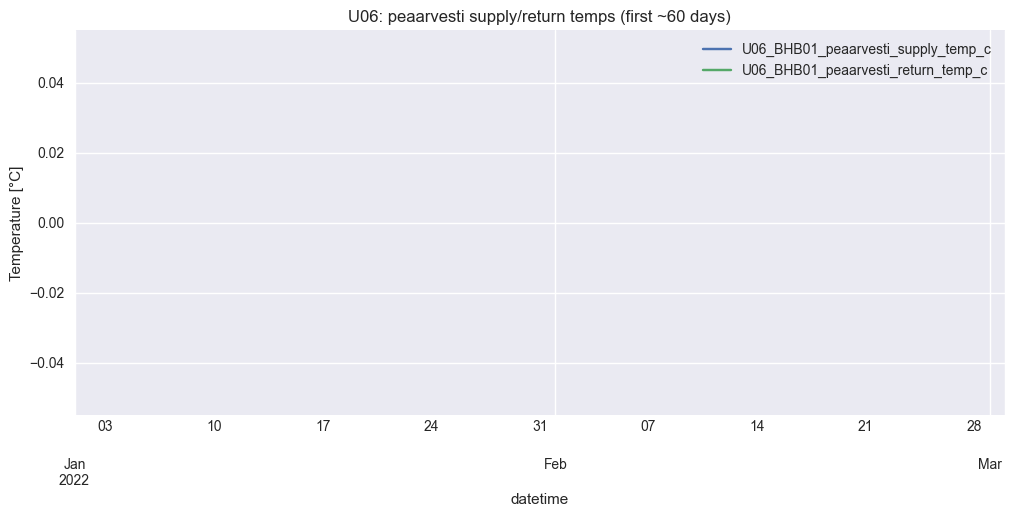

In [34]:
# Section 2b — Critical meter missingness diagnostics (peaarvesti temps)

# Identify critical main-meter temperature columns (supply/return) heuristically
critical_temp_cols = [
    c
    for c in df_building.columns
    if "peaarvesti" in c.lower() and "temp_c" in c.lower()
]

print("Critical peaarvesti temp columns:", critical_temp_cols)

if critical_temp_cols:
    # Plot a sample window for visual inspection (first ~60 days)
    sample_df = df_building[critical_temp_cols].iloc[: 24 * 60]
    ax = sample_df.plot(title=f"{ACTIVE_BUILDING}: peaarvesti supply/return temps (first ~60 days)")
    ax.set_ylabel("Temperature [°C]")

    # Weekly missingness profile over full period
    weekly_missing = df_building[critical_temp_cols].isna().resample("W").mean() * 100.0
    weekly_missing["n_hours"] = df_building[critical_temp_cols[0]].resample("W").size()

    print("\nWeekly missingness [%] for critical temps (per week):")
    display(weekly_missing.tail(12))

    # Weeks where all critical temps are "good" (< 5% missing)
    good_weeks_mask = (weekly_missing[critical_temp_cols] < 5.0).all(axis=1)
    longest_streak = 0
    current = 0
    for is_good in good_weeks_mask:
        if is_good:
            current += 1
            longest_streak = max(longest_streak, current)
        else:
            current = 0

    print("\nGood weeks (all critical temps < 5% missing):", int(good_weeks_mask.sum()))
    print("Longest consecutive run of good weeks:", int(longest_streak))
else:
    print("No peaarvesti temperature columns found in df_building.")

## Global building data coverage (merged hourly CSVs)

For each campus building, this diagnostic computes the **earliest and latest timestamps** available in the merged hourly CSV (`*_hourly_merged.csv`) and a simple coverage ratio.

- This gives you a consistent view of **data availability per building** (e.g. U06 from 2022-03 onwards).
- The results are saved to `results/building_data_coverage.csv` so they can be reused by agents and future notebooks.
- Weather data is continuous and handled separately; this table reflects **building-side meters only**.

In [ ]:
# Global building data coverage diagnostic

from datetime import timedelta


def compute_building_coverage(buildings: list[str]) -> pd.DataFrame:
    rows: list[dict] = []
    for b in buildings:
        path = CLEAN_DATA_DIR / f"{b}_hourly_merged.csv"
        if not path.exists():
            rows.append(
                {
                    "building": b,
                    "start": pd.NaT,
                    "end": pd.NaT,
                    "n_rows": 0,
                    "hours_span": 0,
                    "coverage_ratio": np.nan,
                    "status": "missing_file",
                }
            )
            continue

        df = pd.read_csv(path, usecols=["Time"])
        if df.empty:
            rows.append(
                {
                    "building": b,
                    "start": pd.NaT,
                    "end": pd.NaT,
                    "n_rows": 0,
                    "hours_span": 0,
                    "coverage_ratio": np.nan,
                    "status": "empty",
                }
            )
            continue

        dt = pd.to_datetime(df["Time"])
        start = dt.min()
        end = dt.max()
        n_rows = len(dt)
        hours_span = int((end - start) / pd.Timedelta(hours=1)) + 1
        coverage = n_rows / hours_span if hours_span > 0 else np.nan

        rows.append(
            {
                "building": b,
                "start": start,
                "end": end,
                "n_rows": n_rows,
                "hours_span": hours_span,
                "coverage_ratio": coverage,
                "status": "ok",
            }
        )

    return pd.DataFrame(rows)


building_coverage_df = compute_building_coverage(CAMPUS_BUILDINGS)

# Persist for reuse by other notebooks/agents
coverage_path = RESULTS_DIR / "building_data_coverage.csv"
building_coverage_df.to_csv(coverage_path, index=False)

print(f"Saved building coverage summary to: {coverage_path}")

display(building_coverage_df.sort_values("building"))

In [31]:
# Downstream sections use df_building from the preprocessing cell above.
# Optional: inspect preprocessed columns and target
if not df_building.empty:
    print("Preprocessed columns (sample):", sorted(df_building.columns)[:12], "...")

Preprocessed columns (sample): ['COP_ssrd_W_per_m2', 'COP_temp_c', 'COP_wind_speed_ms', 'KKP_raw_precip_mm', 'KKP_raw_pressure_hpa', 'KKP_raw_sunshine_min', 'KKP_raw_temp_max_c', 'KKP_raw_temp_min_c', 'KKP_raw_wind_ms', 'KKP_sunshine_duration_min', 'KKP_temp_c', 'KKP_wind_speed_ms'] ...


## Quick sanity check of preprocessed data

Before defining the LSTM model, we quickly load one building (by default `GEO`),
apply the preprocessing from Section 1b, resolve the active feature columns, and
plot a short time window. This helps visually confirm that:

- the `heat_kwh` target is continuous and reasonable after cleaning;
- calendar and weather features are present;
- (optionally) building-sensor and EHR features are available when enabled in `FEATURE_CONFIG`.

Building: geo
Total rows: 22,886
Number of selected features: 10
First 10 selected features: ['COP_ssrd_W_per_m2', 'COP_temp_c', 'COP_wind_speed_ms', 'dow_cos', 'dow_sin', 'heat_kwh_hist', 'hour_cos', 'hour_sin', 'month_cos', 'month_sin']


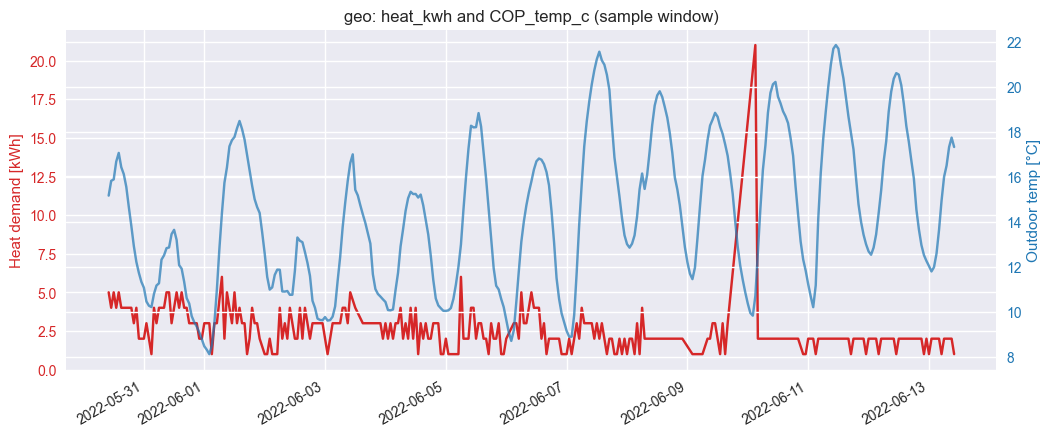

,heat_kwh,COP_temp_c,COP_wind_speed_ms,COP_ssrd_W_per_m2
datetime,,,,
2022-05-30 10:00:00,5.0,15.167145,1.837677,486.44666
2022-05-30 11:00:00,4.0,15.823395,2.161374,555.39610
2022-05-30 12:00:00,5.0,15.888092,2.751027,438.00082
2022-05-30 13:00:00,4.0,16.678375,3.293242,549.61780
2022-05-30 14:00:00,5.0,17.065826,3.301818,503.22333


In [32]:
# Quick exploratory plot for one building (for validation)

example_building = "geo"  # change this to inspect another building

example_df = load_and_preprocess_building_data(example_building)
if example_df.empty:
    raise RuntimeError(f"No data loaded for building {example_building}.")

# Resolve the feature columns based on the current FEATURE_CONFIG
selected_feature_cols = resolve_feature_columns(example_df, FEATURE_CONFIG)
print(f"Building: {example_building}")
print(f"Total rows: {len(example_df):,}")
print(f"Number of selected features: {len(selected_feature_cols)}")
print("First 10 selected features:", selected_feature_cols[:10])

# Choose a convenient recent 2-week window for plotting
start_date = example_df.index.min() + pd.Timedelta(days=7)
end_date = start_date + pd.Timedelta(days=14)
window_df = example_df.loc[start_date:end_date]

fig, ax1 = plt.subplots()

ax1.plot(window_df.index, window_df[TARGET_COLUMN], label="heat_kwh", color="tab:red")
ax1.set_ylabel("Heat demand [kWh]", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

# Overlay outdoor temperature on a secondary axis for context, if available
if "COP_temp_c" in window_df.columns:
    ax2 = ax1.twinx()
    ax2.plot(window_df.index, window_df["COP_temp_c"], label="COP_temp_c", color="tab:blue", alpha=0.7)
    ax2.set_ylabel("Outdoor temp [°C]", color="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:blue")

fig.autofmt_xdate()
plt.title(f"{example_building}: heat_kwh and COP_temp_c (sample window)")
plt.show()

window_df[[TARGET_COLUMN] + [c for c in ["COP_temp_c", "COP_wind_speed_ms", "COP_ssrd_W_per_m2"] if c in window_df.columns]].head()

In [18]:
# Section 3 — Scaling, Windowing, and Metrics

from dataclasses import dataclass
from typing import Tuple

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def extract_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mape = float(np.mean(np.abs((y_true - y_pred) / (y_true + 1e-5))) * 100)
    peak_error = float(np.max(np.abs(y_true - y_pred)))
    r2 = float(r2_score(y_true, y_pred))

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "PeakError": peak_error, "R2": r2}


@dataclass
class Scalers:
    x_scaler: StandardScaler
    y_scaler: StandardScaler


def build_sequences(
    df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    lookback: int,
    split_date: str,
    train_heating_only: bool = True,
    heating_temp_col: str = "COP_temp_c",
    heating_temp_threshold_c: float = 15.0,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, pd.DatetimeIndex]:
    """Build 1-step-ahead sequences.

    Predicts y[t] from X[t-lookback : t] (i.e., history only).

    Returns:
    - X_train, y_train, X_test, y_test arrays
    - test_target_index (timestamps corresponding to y_test)
    """
    if len(df) < (lookback + 10):
        raise ValueError("Not enough rows to build sequences.")

    df = df.copy()

    required = [target_col] + feature_cols
    df = df.dropna(subset=required)

    # Masks (by target timestamp)
    split_ts = pd.Timestamp(split_date)
    is_test = (df.index > split_ts)
    is_train = ~is_test

    if train_heating_only and heating_temp_col in df.columns:
        is_train = is_train & (df[heating_temp_col].to_numpy() < heating_temp_threshold_c)

    # Fit scalers on TRAIN rows only
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_all = df[feature_cols].to_numpy(dtype=np.float32)
    y_all = df[[target_col]].to_numpy(dtype=np.float32)

    x_scaler.fit(X_all[is_train])
    y_scaler.fit(y_all[is_train])

    X_all_s = x_scaler.transform(X_all).astype(np.float32)
    y_all_s = y_scaler.transform(y_all).astype(np.float32).reshape(-1)

    # Build sequences, then select by train/test mask on the target timestamp
    X_seqs: list[np.ndarray] = []
    y_seqs: list[float] = []
    idx_seqs: list[pd.Timestamp] = []

    idx = df.index

    for t in range(lookback, len(df)):
        X_window = X_all_s[t - lookback : t]
        y_t = y_all_s[t]

        X_seqs.append(X_window)
        y_seqs.append(float(y_t))
        idx_seqs.append(idx[t])

    X_seqs = np.stack(X_seqs)
    y_seqs = np.asarray(y_seqs, dtype=np.float32)
    idx_seqs = pd.DatetimeIndex(idx_seqs)

    # Masks for sequence targets
    seq_is_test = idx_seqs > split_ts
    seq_is_train = ~seq_is_test

    if train_heating_only and heating_temp_col in df.columns:
        # Apply heating-season restriction using the temperature at the target timestamp
        temp_at_targets = df.loc[idx_seqs, heating_temp_col]
        seq_is_train = seq_is_train & (temp_at_targets < heating_temp_threshold_c)

    X_train = X_seqs[seq_is_train]
    y_train = y_seqs[seq_is_train]

    X_test = X_seqs[seq_is_test]
    y_test = y_seqs[seq_is_test]
    test_target_index = idx_seqs[seq_is_test]

    return X_train, y_train, X_test, y_test, test_target_index, Scalers(x_scaler=x_scaler, y_scaler=y_scaler)


def inverse_transform_target(y_scaled: np.ndarray, y_scaler: StandardScaler) -> np.ndarray:
    return y_scaler.inverse_transform(np.asarray(y_scaled).reshape(-1, 1)).reshape(-1)


## LSTM model (TensorFlow/Keras)

A simple, readable architecture:

- input: last `LOOKBACK_HOURS` timesteps of selected features
- `LSTM(64)` + small dense head
- early stopping on validation loss

This is intentionally minimal so we can compare fairly against the statistical baselines.

In [19]:
# Section 4 — Model definition


def build_lstm_model(n_features: int) -> keras.Model:
    model = keras.Sequential(
        [
            layers.Input(shape=(LOOKBACK_HOURS, n_features)),
            layers.LSTM(64),
            layers.Dense(32, activation="relu"),
            layers.Dense(1),
        ]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


def make_tf_dataset(X: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> tf.data.Dataset:
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(X), 10_000), seed=42, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


## Per-building training and evaluation

This section loops over buildings, trains one LSTM per building, and evaluates on the 2024 test period.

To keep it practical to run, you can control the scope via `BUILDINGS_TO_RUN`.

In [20]:
# Section 5 — Training loop and evaluation


# Start with a small set for quick iteration; set to CAMPUS_BUILDINGS for a full campus run
BUILDINGS_TO_RUN = ["GEO", "ICO", "U04", "U06"]


def train_one_building(building_code: str) -> dict | None:
    df = load_and_preprocess_building_data(building_code)
    if df.empty:
        print(f"[SKIP] {building_code}: no data")
        return None

    feature_cols = resolve_feature_columns(df, FEATURE_CONFIG)
    if len(feature_cols) == 0:
        print(f"[SKIP] {building_code}: no features selected")
        return None

    # Build sequences (scaled)
    try:
        X_train, y_train, X_test, y_test, test_idx, scalers = build_sequences(
            df=df,
            feature_cols=feature_cols,
            target_col=TARGET_COLUMN,
            lookback=LOOKBACK_HOURS,
            split_date=SPLIT_DATE,
            train_heating_only=TRAIN_HEATING_SEASON_ONLY,
            heating_temp_col="COP_temp_c",
            heating_temp_threshold_c=HEATING_TEMP_THRESHOLD_C,
        )
    except Exception as e:
        print(f"[SKIP] {building_code}: failed to build sequences ({type(e).__name__}: {e})")
        return None

    if len(X_train) < 500 or len(X_test) < 200:
        print(f"[SKIP] {building_code}: insufficient sequences (train={len(X_train)}, test={len(X_test)})")
        return None

    # Chronological train/val split (last 10% for validation)
    n_train = len(X_train)
    n_val = max(1, int(0.1 * n_train))

    X_tr, y_tr = X_train[:-n_val], y_train[:-n_val]
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]

    model = build_lstm_model(n_features=X_train.shape[-1])

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
        )
    ]

    ds_tr = make_tf_dataset(X_tr, y_tr, batch_size=BATCH_SIZE, shuffle=True)
    ds_val = make_tf_dataset(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

    history = model.fit(
        ds_tr,
        validation_data=ds_val,
        epochs=EPOCHS,
        verbose=0,
        callbacks=callbacks,
    )

    # Predict on test
    y_pred_scaled = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).reshape(-1)

    y_true = inverse_transform_target(y_test, scalers.y_scaler)
    y_pred = inverse_transform_target(y_pred_scaled, scalers.y_scaler)

    # Heating season evaluation filter (test period)
    if "COP_temp_c" in df.columns:
        temp_test = df.loc[test_idx, "COP_temp_c"].to_numpy()
        heating_mask = temp_test < HEATING_TEMP_THRESHOLD_C
    else:
        heating_mask = np.ones_like(y_true, dtype=bool)

    metrics = extract_metrics(y_true[heating_mask], y_pred[heating_mask])

    best_val_loss = float(np.min(history.history.get("val_loss", [np.nan])))

    return {
        "Building": building_code,
        "Model": "LSTM",
        **metrics,
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "n_features": int(len(feature_cols)),
        "features": ",".join(feature_cols),
        "best_val_loss_scaled": best_val_loss,
    }


lstm_rows: list[dict] = []

for b in BUILDINGS_TO_RUN:
    print(f"Training LSTM for {b}...")
    row = train_one_building(b)
    if row is not None:
        lstm_rows.append(row)

lstm_metrics_df = pd.DataFrame(lstm_rows)
display(lstm_metrics_df.sort_values("RMSE") if not lstm_metrics_df.empty else lstm_metrics_df)

# Save for reuse
out_file = RESULTS_DIR / "lstm_metrics.csv"
lstm_metrics_df.to_csv(out_file, index=False)
print(f"Saved LSTM metrics to: {out_file}")

Training LSTM for GEO...
Training LSTM for ICO...
Training LSTM for U04...
Training LSTM for U06...


,Building,Model,MAE,RMSE,MAPE,PeakError,R2,n_train,n_test,n_features,features,best_val_loss_scaled
0,GEO,LSTM,0.717378,1.073550,15.236895,11.288638,0.903083,10102,8783,10,"COP_ssrd_W_per_m2,COP_temp_c,COP_wind_speed_ms...",0.064993
1,ICO,LSTM,2.136155,2.946216,19.437166,33.264893,0.972914,10161,8783,10,"COP_ssrd_W_per_m2,COP_temp_c,COP_wind_speed_ms...",0.012398
2,U04,LSTM,11.507661,21.062708,37.599140,84.510765,0.305931,13498,8754,10,"COP_ssrd_W_per_m2,COP_temp_c,COP_wind_speed_ms...",0.166015
3,U06,LSTM,11.090386,25.663536,37.116257,142.442291,0.413758,13498,8754,10,"COP_ssrd_W_per_m2,COP_temp_c,COP_wind_speed_ms...",0.330522


Saved LSTM metrics to: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/lstm_metrics.csv


## Compare LSTM to baselines

This loads the latest baseline metrics (generated by the baseline notebook) and shows a joined comparison for the buildings you ran.

In [21]:
# Section 6 — Baseline comparison table

baseline_file = RESULTS_DIR / "baseline_metrics.csv"
if not baseline_file.exists():
    raise FileNotFoundError(f"Baseline metrics not found at {baseline_file}. Run the baselines notebook first.")

baseline_df = pd.read_csv(baseline_file)

if lstm_metrics_df.empty:
    print("No LSTM results to compare yet.")
else:
    buildings = lstm_metrics_df["Building"].unique().tolist()
    comp = pd.concat(
        [baseline_df[baseline_df["Building"].isin(buildings)], lstm_metrics_df[baseline_df.columns.intersection(lstm_metrics_df.columns)]],
        ignore_index=True,
    )

    comp_pivot = comp.pivot_table(
        index=["Building"],
        columns=["Model"],
        values=["MAE", "RMSE", "MAPE", "R2"],
        aggfunc="first",
    )

    # Flatten columns for readability
    comp_pivot.columns = [f"{metric}_{model}" for metric, model in comp_pivot.columns]
    comp_pivot = comp_pivot.reset_index()

    display(comp_pivot)

    # Quick RMSE ranking per building
    rmse_cols = [c for c in comp_pivot.columns if c.startswith("RMSE_")]
    if rmse_cols:
        tmp = comp_pivot[["Building"] + rmse_cols].copy()
        tmp["best_model_by_rmse"] = tmp[rmse_cols].idxmin(axis=1).str.replace("RMSE_", "", regex=False)
        display(tmp)


,Building,MAE_ARMAX_ES,MAE_ARX_ES,MAE_LSTM,MAE_Persistence,MAE_Static_ES,MAPE_ARMAX_ES,MAPE_ARX_ES,MAPE_LSTM,MAPE_Persistence,...,R2_ARMAX_ES,R2_ARX_ES,R2_LSTM,R2_Persistence,R2_Static_ES,RMSE_ARMAX_ES,RMSE_ARX_ES,RMSE_LSTM,RMSE_Persistence,RMSE_Static_ES
0,GEO,0.695424,0.668848,0.717378,0.682353,1.331668,16.594820,14.152192,15.236895,13.614555,...,0.904385,0.906748,0.903083,0.888649,0.740818,1.059828,1.046653,1.073550,1.143720,1.744920
1,ICO,1.653617,1.555262,2.136155,1.544890,5.653478,11.542777,10.396372,19.437166,7.399574,...,0.979301,0.981412,0.972914,0.980196,0.833589,2.624573,2.487152,2.946216,2.567247,7.441805
2,U04,5.200971,7.875667,11.507661,4.816021,14.875409,43.186338,37.888534,37.599140,21.831930,...,0.843173,0.658399,0.305931,0.791571,-0.198057,8.976219,13.247752,21.062708,10.348134,24.809704
3,U06,7.088921,7.828924,11.090386,5.825161,18.409710,37.106450,40.470063,37.116257,27.419840,...,0.856584,0.828055,0.413758,0.856465,-0.268108,11.106892,12.161552,25.663536,11.111499,33.027201


,Building,RMSE_ARMAX_ES,RMSE_ARX_ES,RMSE_LSTM,RMSE_Persistence,RMSE_Static_ES,best_model_by_rmse
0,GEO,1.059828,1.046653,1.073550,1.143720,1.744920,ARX_ES
1,ICO,2.624573,2.487152,2.946216,2.567247,7.441805,ARX_ES
2,U04,8.976219,13.247752,21.062708,10.348134,24.809704,ARMAX_ES
3,U06,11.106892,12.161552,25.663536,11.111499,33.027201,ARMAX_ES
